In [1]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.cluster import KMeans

In [32]:
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=['sepal_length', 'sepal_width'
                                                , 'petal_length', 'petal_width'])
iris_df.head(3)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [33]:
KM = KMeans(n_clusters=3, init='k-means++',max_iter=300, random_state=0)
KM.fit(iris_df) # 훈련/테스트 분할x
KM.labels_ # 각 데이터가 속한 군집 번호

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [34]:
iris_df['target']=iris.target # 실제값
iris_df['cluster'] = KM.labels_ # 모델이 정한 군집번호
iris_df.head(80)
# 군집의 번호는 달라도 구분이 같다면 ok

,sepal_length,sepal_width,petal_length,petal_width,target,cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1
...,...,...,...,...,...,...
75,6.6,3.0,4.4,1.4,1,0
76,6.8,2.8,4.8,1.4,1,0
77,6.7,3.0,5.0,1.7,1,2
78,6.0,2.9,4.5,1.5,1,0


In [35]:
iris_df.groupby(['target','cluster'])['sepal_length'].count()

target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64

# 군집의 평가 : 실루엣계수

In [36]:
from sklearn.metrics import silhouette_score, silhouette_samples
iris_df['silhouette_coeff'] = silhouette_samples(iris.data, iris_df['cluster'])
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,silhouette_coeff
0,5.1,3.5,1.4,0.2,0,1,0.852582
1,4.9,3.0,1.4,0.2,0,1,0.814916
2,4.7,3.2,1.3,0.2,0,1,0.828797
3,4.6,3.1,1.5,0.2,0,1,0.804352
4,5.0,3.6,1.4,0.2,0,1,0.848918


In [37]:
silhouette_score(iris.data, iris_df['cluster'])

0.5511916046195919

In [38]:
score_sample = silhouette_samples(iris.data, iris_df['cluster']) 

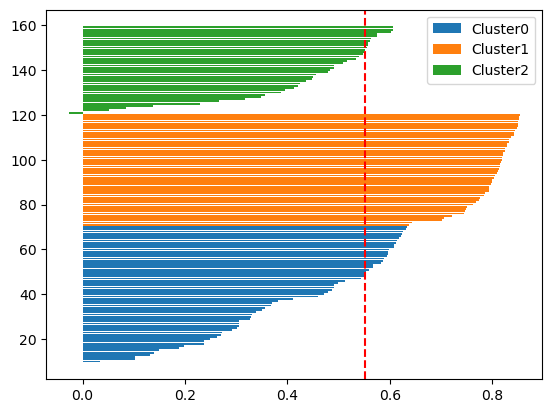

In [39]:
# 실루엣계수 시각화
import matplotlib.pyplot as plt
y_lower = 10

for i in range(3):
  cluster_i =score_sample[iris_df['cluster']==i]
  cluster_i.sort()
  y_upper=y_lower+len(cluster_i)
  plt.barh(range(y_lower, y_upper), cluster_i, label=f'Cluster{i}')
  y_lower = y_upper 

avg_score = silhouette_score(iris.data, iris_df['cluster'])
plt.axvline(avg_score, color='red', linestyle = '--')
plt.legend()
plt.show()

k의 값을 조정
데이터 스케일링

# k값의 선택을 위한 스크리 차트

In [40]:
scree_df = iris_df[['sepal_length','sepal_width','petal_length','petal_width']]
sse_values=[]

k_values = range(1,11)
for k in k_values:
  kmeans = KMeans(n_clusters=k, init='k-means++',max_iter=300, random_state=0)
  kmeans.fit(scree_df)
  sse_values.append(kmeans.inertia_)

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

In [41]:
sse_values

[681.3706,
 152.34795176035792,
 78.85566582597728,
 57.228473214285714,
 49.82774055829229,
 42.42154575309748,
 34.420191786283894,
 30.064593073593073,
 28.715856536394465,
 27.46211879129643]

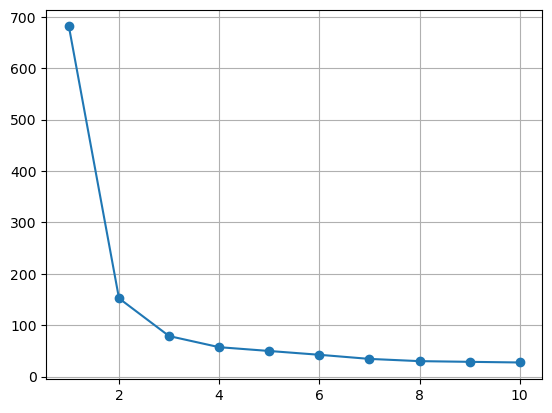

In [42]:
plt.plot(k_values, sse_values, marker='o')
plt.grid()
plt.show()

# iris_df의 차원축소

In [43]:
from sklearn.decomposition import PCA

# PCA 객체 생성 (주성분 2개로 축소)
pca = PCA(n_components=2)

# 데이터 변환
X_pca = pca.fit_transform(iris.data)

# 설명된 분산 비율 확인
print(pca.explained_variance_ratio_)

[0.92461872 0.05306648]


In [44]:
iris_df['pca_x']=X_pca[:,0]
iris_df['pca_y']=X_pca[:,1]
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,silhouette_coeff,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,0.852582,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,0.814916,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,0.828797,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,0,1,0.804352,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,0,1,0.848918,-2.728717,0.326755


In [45]:
X_pca

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943],
       [-2.74534286, -0.31829898],
       [-2.72871654,  0.32675451],
       [-2.28085963,  0.74133045],
       [-2.82053775, -0.08946138],
       [-2.62614497,  0.16338496],
       [-2.88638273, -0.57831175],
       [-2.6727558 , -0.11377425],
       [-2.50694709,  0.6450689 ],
       [-2.61275523,  0.01472994],
       [-2.78610927, -0.235112  ],
       [-3.22380374, -0.51139459],
       [-2.64475039,  1.17876464],
       [-2.38603903,  1.33806233],
       [-2.62352788,  0.81067951],
       [-2.64829671,  0.31184914],
       [-2.19982032,  0.87283904],
       [-2.5879864 ,  0.51356031],
       [-2.31025622,  0.39134594],
       [-2.54370523,  0.43299606],
       [-3.21593942,  0.13346807],
       [-2.30273318,  0.09870885],
       [-2.35575405, -0.03728186],
       [-2.50666891, -0.14601688],
       [-2.46882007,  0.13095149],
       [-2.56231991,  0.36771886],
       [-2.63953472,

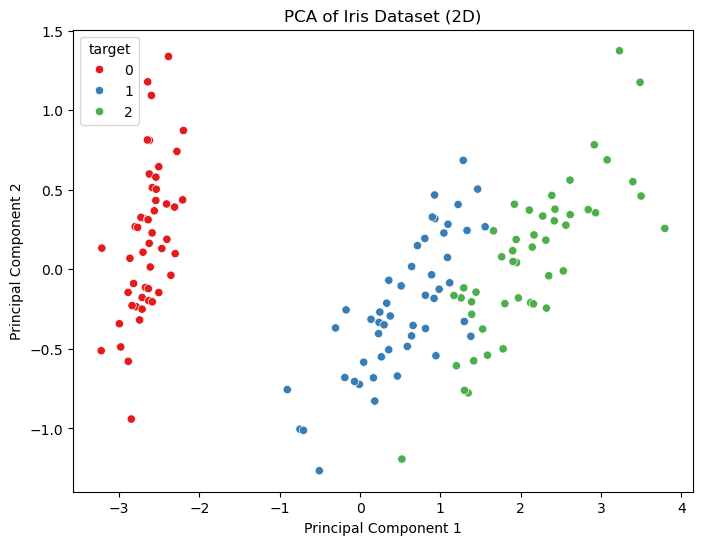

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

# hue='target' 부분은 iris_df에 있는 실제 품종 컬럼명(예: target 또는 species)으로 맞춰주세요.
sns.scatterplot(
    x='pca_x', 
    y='pca_y', 
    hue='target', 
    palette='Set1', 
    data=iris_df
)

plt.title('PCA of Iris Dataset (2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# 그래프 출력
plt.show()

In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# 스케일링 
scaler = StandardScaler()
iris_scaled = scaler.fit_transform(iris.data)
# PCA 객체 생성 및 데이터 변환 (스케일링된 데이터 사용)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(iris_scaled)
# 설명된 분산 비율 확인
print("설명된 분산 비율:", pca.explained_variance_ratio_)

# # 데이터프레임에 결과 추가
# iris_df['pca_x'] = X_pca[:, 0]
# iris_df['pca_y'] = X_pca[:, 1]
# iris_df['target'] = iris.target # 시각화를 위해 정답 데이터도 추가

# print(iris_df.head())

설명된 분산 비율: [0.72962445 0.22850762]
